# Basics

In [21]:
student = "/home/noir/Documents/Code/data/Student_performance.csv"

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


def load_data(file_path):
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        return df
    else:
        print(f"File not found: {file_path}")
        return None

In [23]:
df_student = load_data(student)
df_student.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [40]:
numerical_col = df_student.select_dtypes(include=np.number).columns.tolist()
categorical_col = df_student.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:", numerical_col)
print("Categorical Columns:", categorical_col)  

Numerical Columns: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass', 'StudyTimeWeekly_log']
Categorical Columns: []


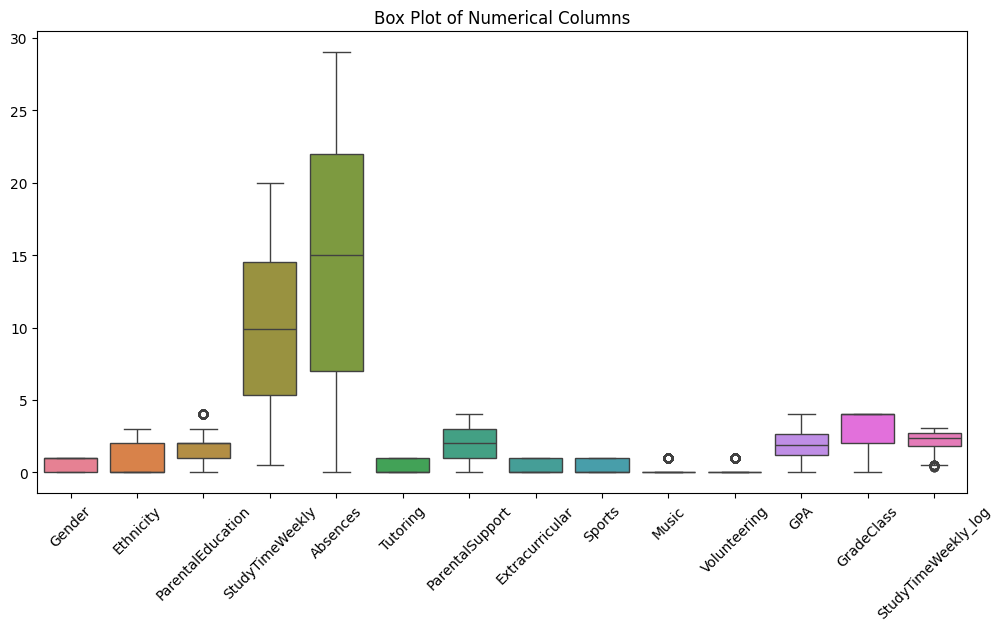

In [46]:
# box plot all numerical columns in single graph
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_student[numerical_col[2:]])
plt.title("Box Plot of Numerical Columns")
plt.xticks(rotation=45)
plt.show()

In [ ]:
fromffrfffkkfkkffkkffffffff      

In [ ]:
model = LinearRegression()
model.fit(df_student["StudyTimeWeekly_log"].values.reshape(-1, 1), df_student["GPA"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept: (c)", model.intercept_)   

Slope (Coefficient): 0.029023744613935816
Intercept: (c) 1.6225665048875095


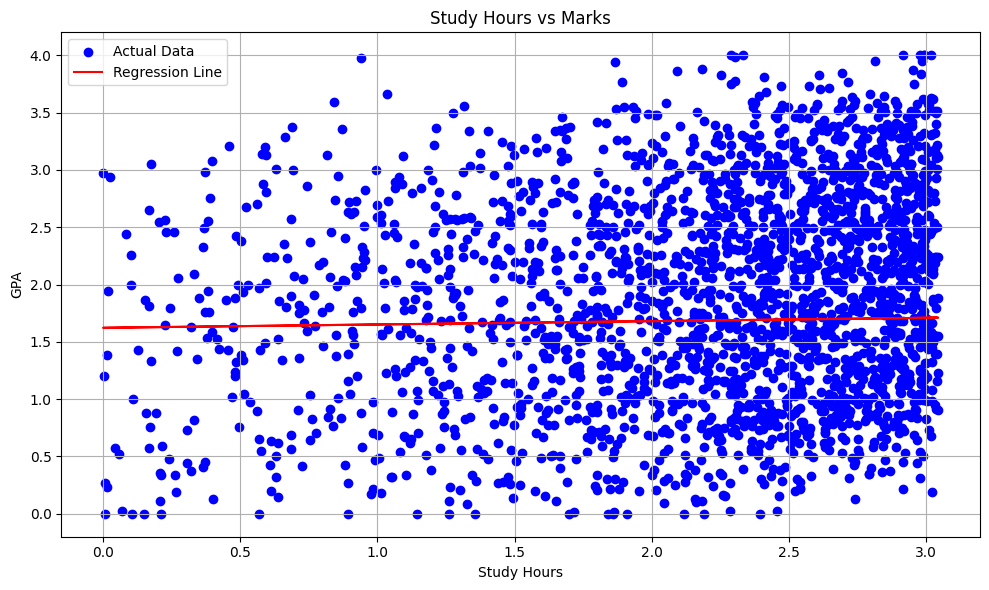

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(df_student["StudyTimeWeekly_log"], df_student["GPA"], color="blue", label="Actual Data")
predicted_gpa = model.predict(df_student["StudyTimeWeekly_log"].values.reshape(-1, 1))

plt.plot(df_student["StudyTimeWeekly_log"], predicted_gpa, color="red", label="Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Study Hours vs Marks")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
